In [5]:
import pandas as pd
df = pd.read_csv("Telco_Customer_Churn.csv.csv")

In [6]:
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [7]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [2]:
import pandas as pd

df = pd.read_csv("Telco_Customer_Churn.csv.csv")


In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("COLUMN NAMES")
print(df.columns)

COLUMN NAMES
Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')


In [5]:
print("\n MISSING VALUES BEFORE CLEANING ")
print(df.isnull().sum())



 MISSING VALUES BEFORE CLEANING 
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [7]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())


categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n MISSING VALUES AFTER CLEANING ")
print(df.isnull().sum())


 MISSING VALUES AFTER CLEANING 
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [8]:
print("\n DUPLICATE RECORDS ")
print(df.duplicated().sum())


 DUPLICATE RECORDS 
0


In [9]:
df = df.drop_duplicates()

print("\n DATASET SHAPE AFTER REMOVING DUPLICATES ")
print(df.shape)


 DATASET SHAPE AFTER REMOVING DUPLICATES 
(7043, 21)


In [10]:
print(" MEAN ")
print(df.mean(numeric_only=True))

print("\n MEDIAN ")
print(df.median(numeric_only=True))

print("\n MODE ")
print(df.mode().head())

 MEAN 
seniorcitizen      0.162147
tenure            32.371149
monthlycharges    64.761692
dtype: float64

 MEDIAN 
seniorcitizen      0.00
tenure            29.00
monthlycharges    70.35
dtype: float64

 MODE 
   customerid gender  seniorcitizen partner dependents  tenure phoneservice  \
0  0002-ORFBO   Male            0.0      No         No     1.0          Yes   
1  0003-MKNFE    NaN            NaN     NaN        NaN     NaN          NaN   
2  0004-TLHLJ    NaN            NaN     NaN        NaN     NaN          NaN   
3  0011-IGKFF    NaN            NaN     NaN        NaN     NaN          NaN   
4  0013-EXCHZ    NaN            NaN     NaN        NaN     NaN          NaN   

  multiplelines internetservice onlinesecurity  ... deviceprotection  \
0            No     Fiber optic             No  ...               No   
1           NaN             NaN            NaN  ...              NaN   
2           NaN             NaN            NaN  ...              NaN   
3           NaN           

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

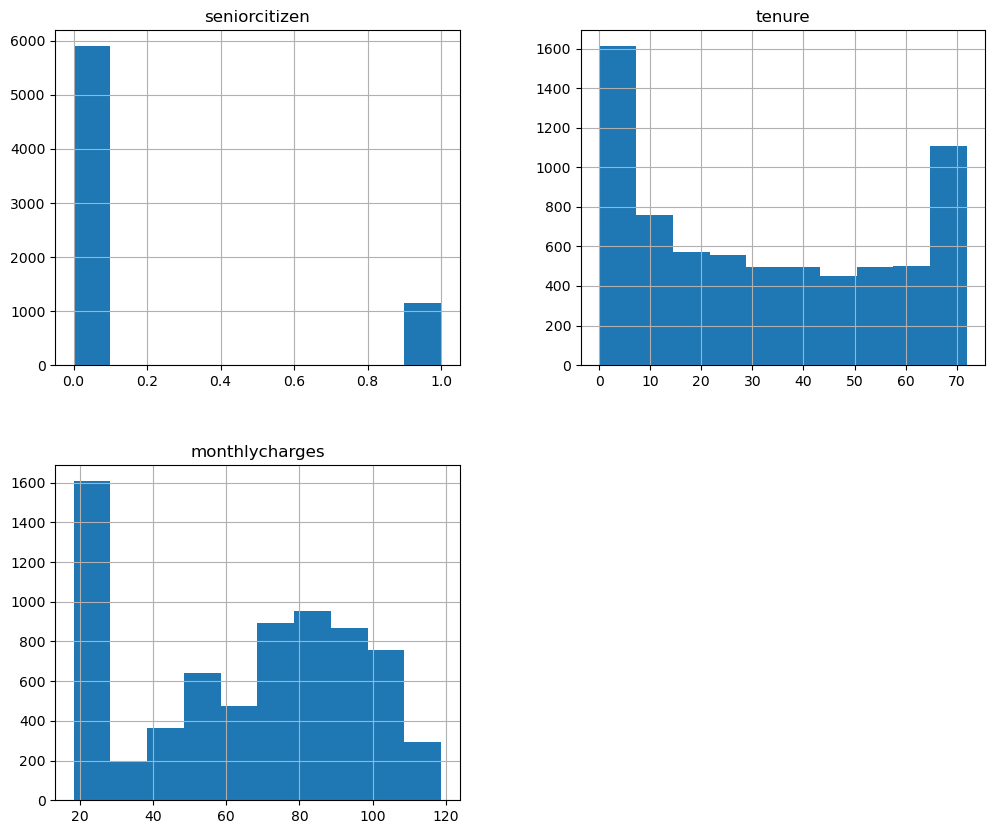

In [14]:
df.hist(figsize=(12,10))
plt.show()

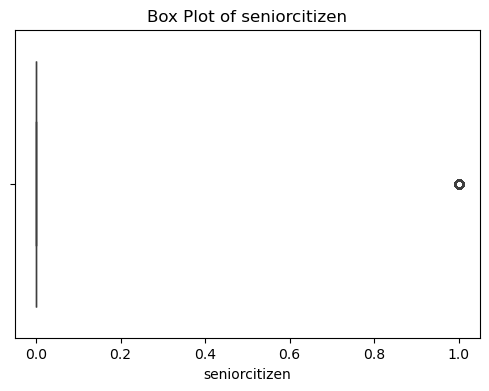

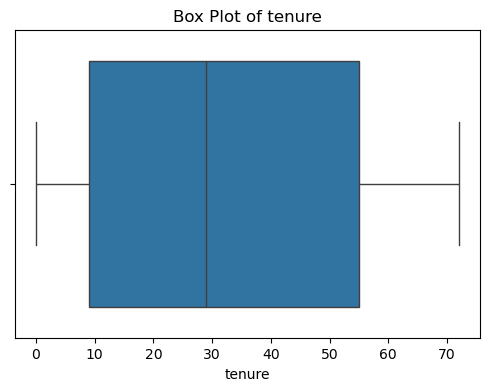

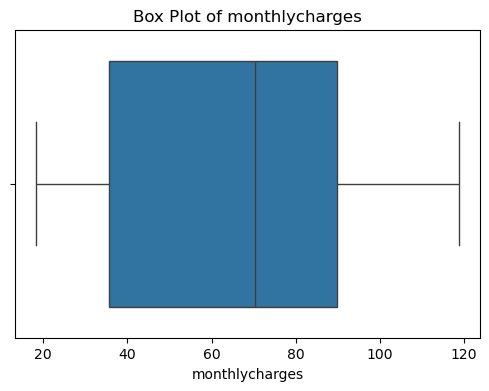

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()


 CHURN COUNTS 
churn
No     5174
Yes    1869
Name: count, dtype: int64


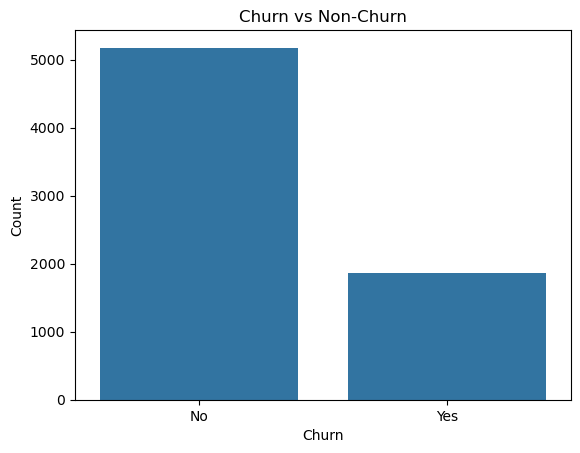

In [18]:
print("\n CHURN COUNTS ")
print(df['churn'].value_counts())

sns.countplot(x='churn', data=df)

plt.title("Churn vs Non-Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [19]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 36:
        return "13-36 Months"
    else:
        return "37+ Months"

df['tenure_category'] = df['tenure'].apply(tenure_group)

print(df[['tenure', 'tenure_category']].head())

   tenure tenure_category
0       1     0-12 Months
1      34    13-36 Months
2       2     0-12 Months
3      45      37+ Months
4       2     0-12 Months


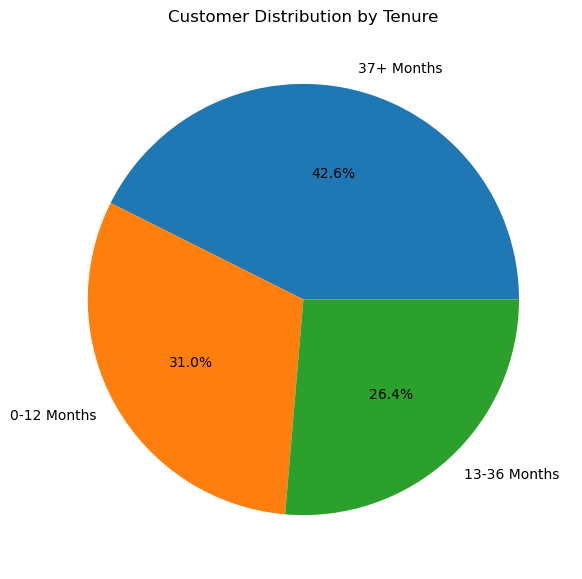

In [20]:
tenure_counts = df['tenure_category'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tenure_counts,
    labels=tenure_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Distribution by Tenure")

plt.show()

In [22]:
avg_charges = df.groupby('tenure_category')['monthlycharges'].mean().reset_index()

print(avg_charges)

  tenure_category  monthlycharges
0     0-12 Months       56.097781
1    13-36 Months       63.248195
2      37+ Months       72.008730


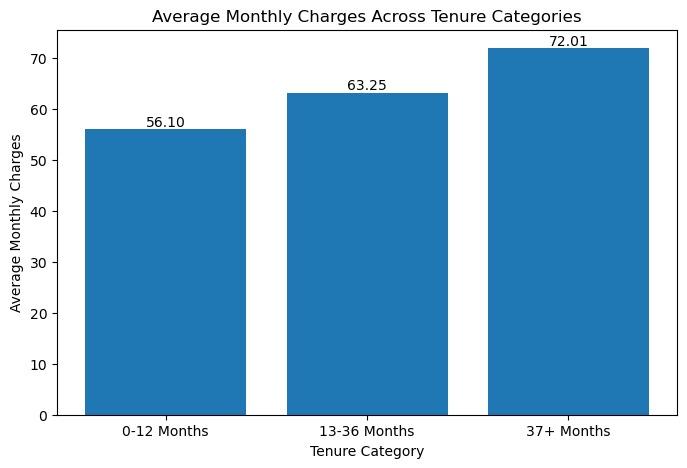

In [23]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    avg_charges['tenure_category'],
    avg_charges['monthlycharges']
)

plt.title("Average Monthly Charges Across Tenure Categories")
plt.xlabel("Tenure Category")
plt.ylabel("Average Monthly Charges")

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [25]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 36:
        return "13-36 Months"
    else:
        return "37+ Months"

df['tenure_group'] = df['tenure'].apply(tenure_group)

In [26]:
tenure_analysis = df.groupby('tenure_group').agg({
    'monthlycharges': ['mean', 'min', 'max'],
    'tenure': 'count'
})

print("===== TENURE ANALYSIS =====")
print(tenure_analysis)

===== TENURE ANALYSIS =====
             monthlycharges                tenure
                       mean    min     max  count
tenure_group                                     
0-12 Months       56.097781  18.75  112.95   2186
13-36 Months      63.248195  18.25  116.25   1856
37+ Months        72.008730  18.40  118.75   3001


churn     No  Yes
gender           
Female  2549  939
Male    2625  930


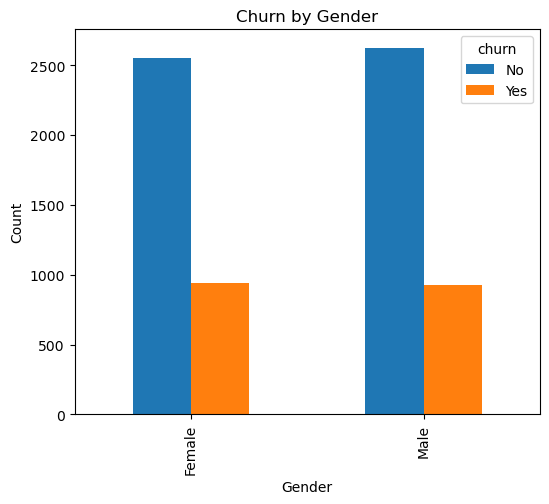

In [27]:
gender_churn = pd.crosstab(df['gender'], df['churn'])

print(gender_churn)

gender_churn.plot(kind='bar', figsize=(6,5))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

churn            No   Yes
seniorcitizen            
0              4508  1393
1               666   476


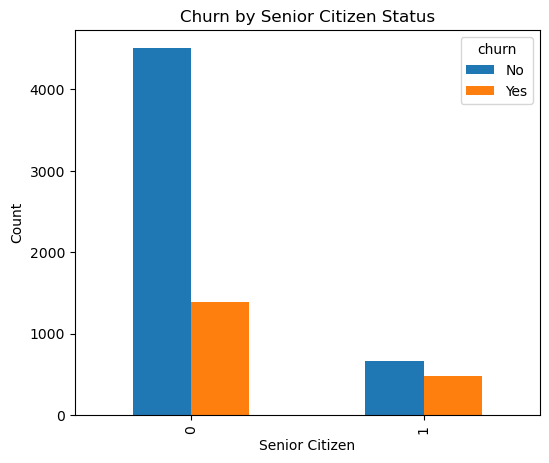

In [28]:
senior_churn = pd.crosstab(df['seniorcitizen'], df['churn'])

print(senior_churn)

senior_churn.plot(kind='bar', figsize=(6,5))

plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")

plt.show()

churn                        No   Yes
paymentmethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


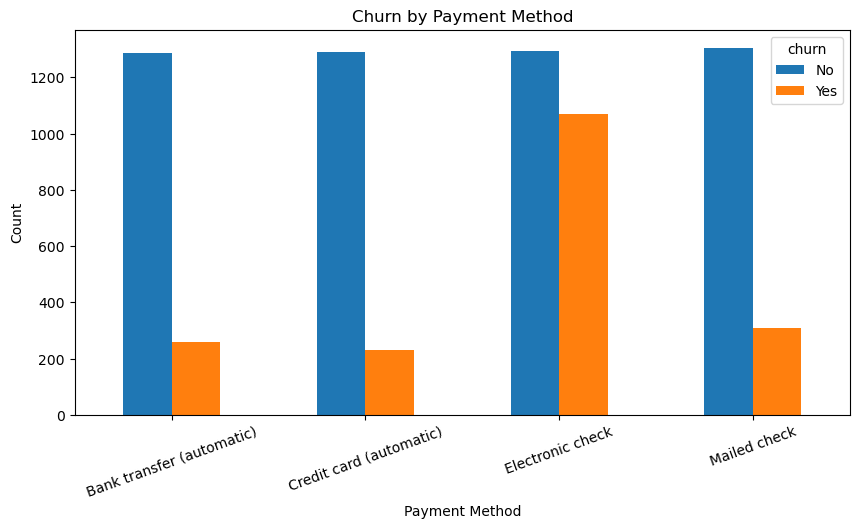

In [29]:
payment_churn = pd.crosstab(df['paymentmethod'], df['churn'])

print(payment_churn)

payment_churn.plot(kind='bar', figsize=(10,5))

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

churn             No   Yes
contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


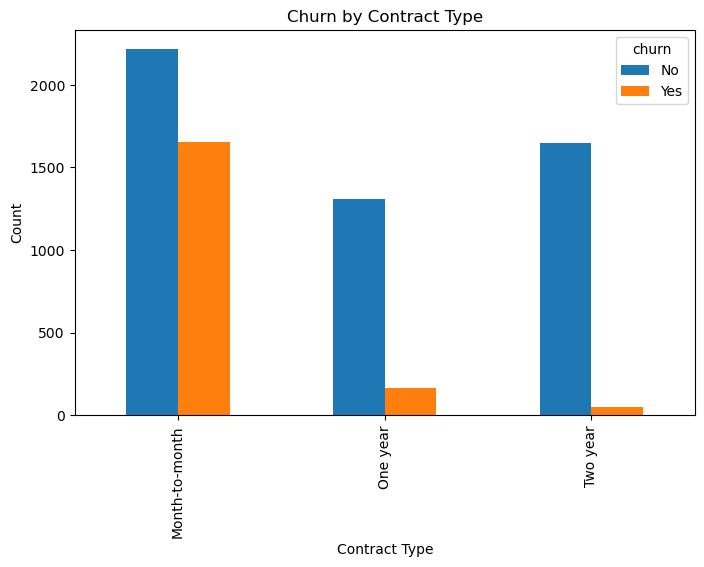

In [30]:
contract_churn = pd.crosstab(df['contract'], df['churn'])

print(contract_churn)

contract_churn.plot(kind='bar', figsize=(8,5))

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.show()

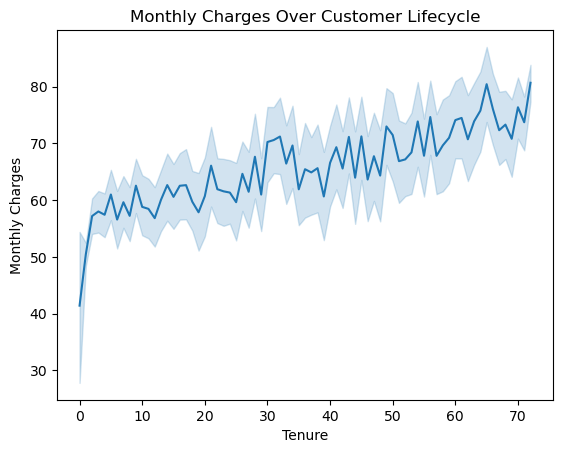

In [31]:
sns.lineplot(
    x='tenure',
    y='monthlycharges',
    data=df
)

plt.title("Monthly Charges Over Customer Lifecycle")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()